In [1]:
from datascience import *
%matplotlib inline
path_data = 'data/'
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# 최소 제곱법 (The Method of Least Squares)
우리는 럭비공 모양의 산점도를 통과하는 회귀선의 방정식을 개발했습니다. 하지만 모든 산점도가 럭비공 모양인 것은 아니며, 선형인 경우에도 마찬가지입니다. 모든 산점도에는 그것을 통과하는 "최적의" 선이 있을까요? 만약 그렇다면, 이전 섹션에서 개발한 기울기와 절편에 대한 공식을 여전히 사용할 수 있을까요, 아니면 새로운 공식이 필요할까요?

이러한 질문을 해결하려면 "최적"에 대한 합리적인 정의가 필요합니다. 선의 목적은 $x$ 값이 주어졌을 때 $y$ 값을 *예측*하거나 *추정*하는 것임을 상기하십시오. 추정치는 일반적으로 완벽하지 않습니다. 각각은 실제 값에서 *오차(error)*만큼 벗어나 있습니다. 선이 "최적"이 되기 위한 합리적인 기준은 모든 직선 중에서 가능한 가장 작은 전체 오차를 갖는 것입니다.

이 섹션에서는 이 기준을 정확하게 만들고 그 기준에 따라 최적의 직선을 식별할 수 있는지 알아볼 것입니다.

In [3]:
def standard_units(any_numbers):
    "Convert any array of numbers to standard units."
    return (any_numbers - np.mean(any_numbers))/np.std(any_numbers)

def correlation(t, x, y):
    return np.mean(standard_units(t.column(x))*standard_units(t.column(y)))

def slope(table, x, y):
    r = correlation(table, x, y)
    return r * np.std(table.column(y))/np.std(table.column(x))

def intercept(table, x, y):
    a = slope(table, x, y)
    return np.mean(table.column(y)) - a * np.mean(table.column(x))

def fit(table, x, y):
    """Return the height of the regression line at each x value."""
    a = slope(table, x, y)
    b = intercept(table, x, y)
    return a * table.column(x) + b

첫 번째 예제는 소설 "작은 아씨들(Little Women)"의 모든 챕터에 대해 하나의 행을 갖는 데이터 세트입니다. 목표는 마침표의 수를 기반으로 문자(즉, 글자, 공백, 문장 부호 등)의 수를 추정하는 것입니다. 이 과정의 가장 첫 번째 강의에서 이것을 시도했음을 상기하십시오.

In [4]:
little_women = Table.read_table(path_data + 'little_women.csv')
little_women = little_women.move_to_start('Periods')
little_women.show(3)

Periods,Characters
189,21759
188,22148
231,20558


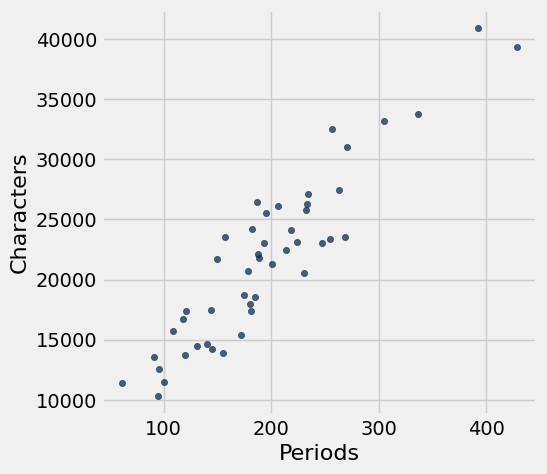

In [6]:
little_women.scatter('Periods', 'Characters')

데이터를 탐색하려면 이전 섹션에서 정의한 `correlation`, `slope`, `intercept`, `fit` 함수를 사용해야 합니다.

In [7]:
correlation(little_women, 'Periods', 'Characters')

0.92295768958548163

산점도는 놀랍게도 선형에 가깝고 상관관계는 0.92 이상입니다.

## 추정 오차

아래 그래프는 이전 섹션에서 개발한 산점도와 선을 보여줍니다. 그것이 모든 선 중에서 최적인지는 아직 모릅니다. 먼저 "최적"이 무엇을 의미하는지 정확하게 말해야 합니다.

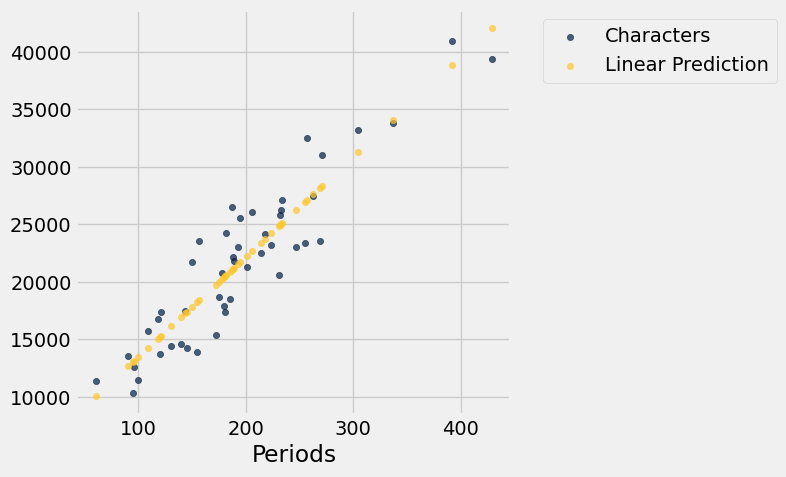

In [8]:
lw_with_predictions = little_women.with_column('Linear Prediction', fit(little_women, 'Periods', 'Characters'))
lw_with_predictions.scatter('Periods')

산점도의 각 점에 대응하여 실제 값에서 예측 값을 뺀 값으로 계산된 예측 오차가 있습니다. 이것은 점과 선 사이의 수직 거리이며, 점이 선 아래에 있으면 음의 부호를 갖습니다.

In [9]:
actual = lw_with_predictions.column('Characters')
predicted = lw_with_predictions.column('Linear Prediction')
errors = actual - predicted

In [10]:
lw_with_predictions.with_column('Error', errors)

Periods,Characters,Linear Prediction,Error
189,21759,21183.6,575.403
188,22148,21096.6,1051.38
231,20558,24836.7,-4278.67
195,25526,21705.5,3820.54
255,23395,26924.1,-3529.13
140,14622,16921.7,-2299.68
131,14431,16138.9,-1707.88
214,22476,23358,-882.043
337,33767,34056.3,-289.317
185,18508,20835.7,-2327.69


`slope`와 `intercept`를 사용하여 적합선의 기울기와 절편을 계산할 수 있습니다. 아래 그래프는 선(연한 파란색)을 보여줍니다. 네 개의 점에 해당하는 오차는 빨간색으로 표시됩니다. 그 네 점에 특별한 점은 없습니다. 단지 디스플레이의 명확성을 위해 선택되었습니다. `lw_errors` 함수는 기울기와 절편(순서대로)을 인수로 받아 그림을 그립니다.

In [11]:
lw_reg_slope = slope(little_women, 'Periods', 'Characters')
lw_reg_intercept = intercept(little_women, 'Periods', 'Characters')

In [12]:

sample = [[131, 14431], [231, 20558], [392, 40935], [157, 23524]]
def lw_errors(slope, intercept):
    little_women.scatter('Periods', 'Characters')
    xlims = np.array([50, 450])
    plots.plot(xlims, slope * xlims + intercept, lw=2)
    for x, y in sample:
        plots.plot([x, x], [y, slope * x + intercept], color='r', lw=2)

Slope of Regression Line:     87.0 characters per period
Intercept of Regression Line: 4745.0 characters


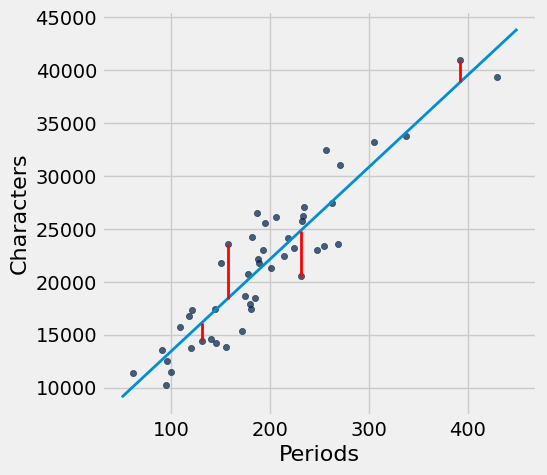

In [13]:
print('Slope of Regression Line:    ', np.round(lw_reg_slope), 'characters per period')
print('Intercept of Regression Line:', np.round(lw_reg_intercept), 'characters')
lw_errors(lw_reg_slope, lw_reg_intercept)

추정치를 생성하기 위해 다른 선을 사용했다면 오차가 달랐을 것입니다. 아래 그래프는 추정을 위해 다른 선을 사용했을 때 오차가 얼마나 클지를 보여줍니다. 두 번째 그래프는 터무니없는 선을 사용하여 얻은 큰 오차를 보여줍니다.

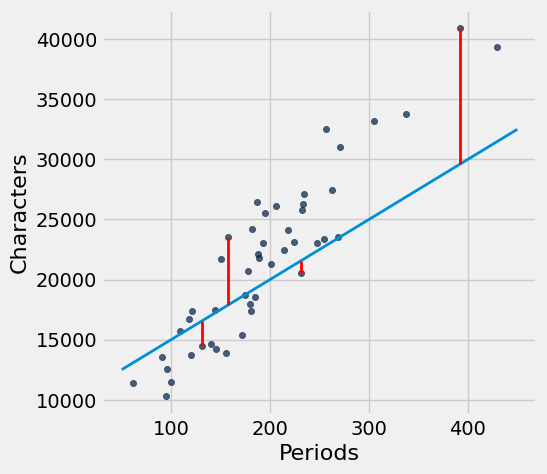

In [ ]:
lw_errors(50, 10000)

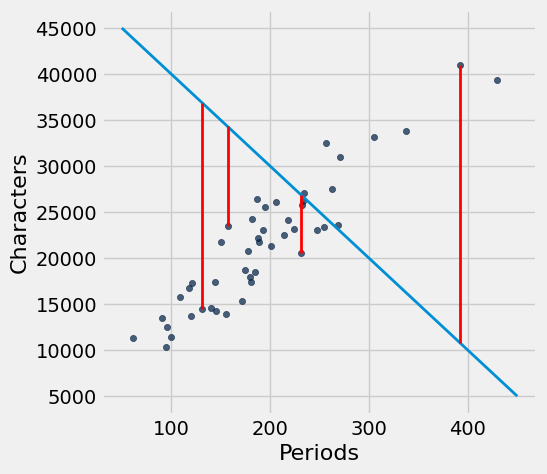

In [ ]:
lw_errors(-100, 50000)

## 평균 제곱근 오차 (Root Mean Squared Error)

이제 우리에게 필요한 것은 오차의 대략적인 크기에 대한 하나의 전체적인 척도입니다. 이것을 만드는 접근 방식을 알아볼 것입니다 – 이것은 우리가 표준 편차(SD)를 개발한 방식과 정확히 같습니다.

임의의 선을 사용하여 추정치를 계산하면 오차 중 일부는 양수이고 다른 일부는 음수일 가능성이 높습니다. 오차의 대략적인 크기를 측정할 때 상쇄를 피하기 위해 오차 자체의 평균이 아니라 오차 제곱의 평균을 취할 것입니다.

추정의 평균 제곱 오차는 제곱 오차가 대략 얼마나 큰지를 나타내는 척도이지만, 앞서 언급했듯이 그 단위는 해석하기 어렵습니다. 제곱근을 취하면 평균 제곱근 오차(rmse)가 산출되며, 이는 예측되는 변수와 동일한 단위이므로 이해하기 훨씬 쉽습니다.

## 평균 제곱근 오차 최소화

지금까지의 관찰 내용은 다음과 같이 요약할 수 있습니다.

- $x$를 기반으로 $y$의 추정치를 얻기 위해 원하는 어떤 선이든 사용할 수 있습니다.
- 모든 선에는 추정의 평균 제곱근 오차가 있습니다.
- "더 나은" 선은 더 작은 오차를 가집니다.

"최적"의 선이 있을까요? 즉, 모든 선 중에서 평균 제곱근 오차를 최소화하는 선이 있을까요?

이 질문에 답하기 위해 "작은 아씨들" 산점도를 통과하는 임의의 선에 대한 평균 제곱근 오차를 계산하는 `lw_rmse` 함수를 정의하는 것으로 시작하겠습니다. 이 함수는 기울기와 절편(순서대로)을 인수로 받습니다.

In [14]:
def lw_rmse(slope, intercept):
    lw_errors(slope, intercept)
    x = little_women.column('Periods')
    y = little_women.column('Characters')
    fitted = slope * x + intercept
    mse = np.mean((y - fitted) ** 2)
    print("Root mean squared error:", mse ** 0.5)

Root mean squared error: 4322.16783177


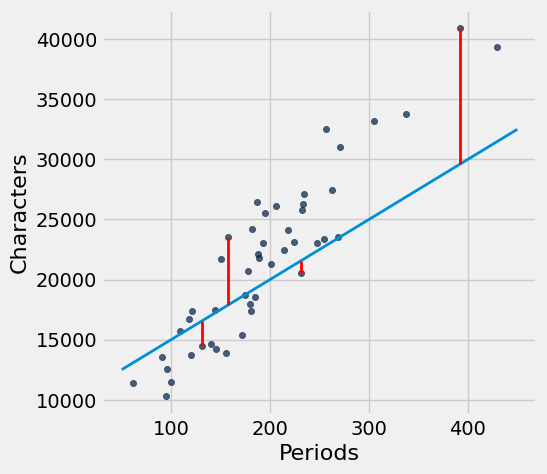

In [15]:
lw_rmse(50, 10000)

Root mean squared error: 16710.1198374


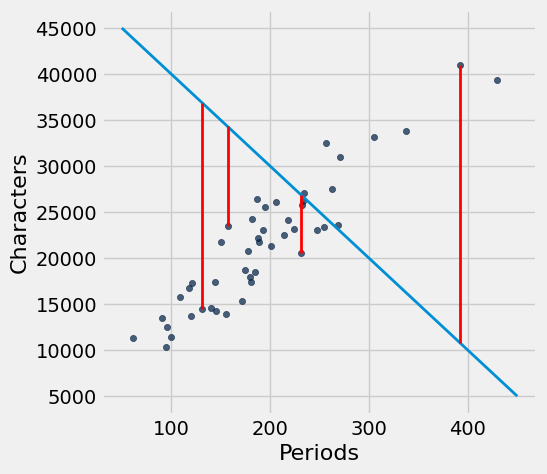

In [16]:
lw_rmse(-100, 50000)

Bad lines have big values of rmse, as expected. But the rmse is much smaller if we choose a slope and intercept close to those of the regression line.

Root mean squared error: 2715.53910638


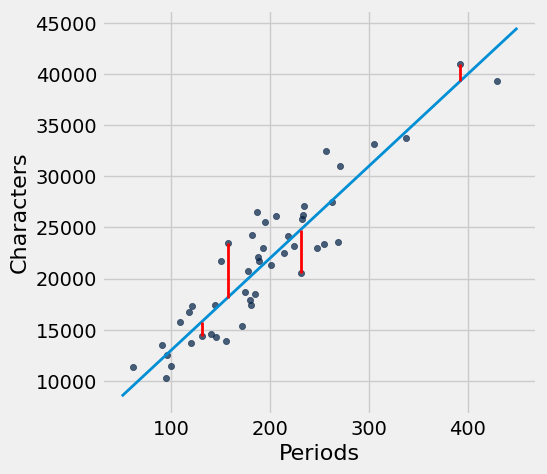

In [17]:
lw_rmse(90, 4000)

Here is the root mean squared error corresponding to the regression line. By a remarkable fact of mathematics, no other line can beat this one.

- **The regression line is the unique straight line that minimizes the mean squared error of estimation among all straight lines.**

Root mean squared error: 2701.69078531


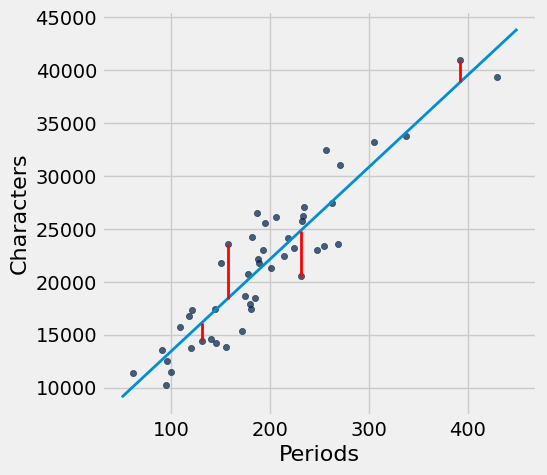

In [18]:
lw_rmse(lw_reg_slope, lw_reg_intercept)

The proof of this statement requires abstract mathematics that is beyond the scope of this course. On the other hand, we do have a powerful tool – Python – that performs large numerical computations with ease. So we can use Python to confirm that the regression line minimizes the mean squared error.

### Numerical Optimization ###
First note that a line that minimizes the root mean squared error is also a line that minimizes the squared error. The square root makes no difference to the minimization. So we will save ourselves a step of computation and just minimize the mean squared error (mse).

We are trying to predict the number of characters ($y$) based on the number of periods ($x$) in chapters of Little Women. If we use the line

$$
\mbox{prediction} ~=~ ax + b
$$

it will have an mse that depends on the slope $a$ and the intercept $b$. The function `lw_mse` takes the slope and intercept as its arguments and returns the corresponding mse.

In [19]:
def lw_mse(any_slope, any_intercept):
    x = little_women.column('Periods')
    y = little_women.column('Characters')
    fitted = any_slope*x + any_intercept
    return np.mean((y - fitted) ** 2)

Let's check that `lw_mse` gets the right answer for the root mean squared error of the regression line. Remember that `lw_mse` returns the mean squared error, so we have to take the square root to get the rmse.

In [20]:
lw_mse(lw_reg_slope, lw_reg_intercept)**0.5

2701.690785311856

That's the same as the value we got by using `lw_rmse` earlier:

Root mean squared error: 2701.69078531


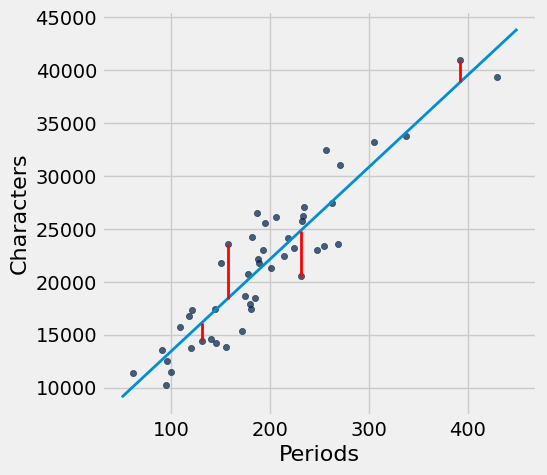

In [21]:
lw_rmse(lw_reg_slope, lw_reg_intercept)

You can confirm that `lw_mse` returns the correct value for other slopes and intercepts too. For example, here is the rmse of the extremely bad line that we tried earlier.

In [22]:
lw_mse(-100, 50000)**0.5

16710.119837353752

And here is the rmse for a line that is close to the regression line.

In [23]:
lw_mse(90, 4000)**0.5

2715.5391063834586

If we experiment with different values, we can find a low-error slope and intercept through trial and error, but that would take a while. Fortunately, there is a Python function that does all the trial and error for us.

The `minimize` function can be used to find the arguments of a function for which the function returns its minimum value. Python uses a similar trial-and-error approach, following the changes that lead to incrementally lower output values.

The argument of `minimize` is a function that itself takes numerical arguments and returns a numerical value. For example, the function `lw_mse` takes a numerical slope and intercept as its arguments and returns the corresponding mse.

The call `minimize(lw_mse)` returns an array consisting of the slope and the intercept that minimize the mse. These minimizing values are excellent approximations arrived at by intelligent trial-and-error, not exact values based on formulas.

In [24]:
best = minimize(lw_mse)
best

array([   86.97784117,  4744.78484535])

These values are the same as the values we calculated earlier by using the `slope` and `intercept` functions. We see small deviations due to the inexact nature of `minimize`, but the values are essentially the same.

In [25]:
print("slope from formula:        ", lw_reg_slope)
print("slope from minimize:       ", best.item(0))
print("intercept from formula:    ", lw_reg_intercept)
print("intercept from minimize:   ", best.item(1))

slope from formula:         86.9778412583
slope from minimize:        86.97784116615884
intercept from formula:     4744.78479657
intercept from minimize:    4744.784845352655


## The Least Squares Line

Therefore, we have found not only that the regression line minimizes mean squared error, but also that minimizing mean squared error gives us the regression line. The regression line is the only line that minimizes mean squared error.

That is why the regression line is sometimes called the "least squares line."